In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def calculate_probability(x, n, Omega):
    """
    计算 P(\vec{x}|n) 的概率

    参数:
    x (array-like): 输入向量 \vec{x}
    n (array-like): 参数向量 n
    Omega (function): 计算 \Omega_j(\vec{x}) 的函数
    
    返回:
    float: 概率值 P(\vec{x}|n)
    """
    N = len(n)
    product = 1.0
    for j in range(N):
        Omega_j = Omega(x, j)
        product *= np.exp(n[j] * np.log(Omega_j))
    return product

def example_Omega(x, j):
    # 这是一个示例的 Omega 函数，用户可以根据实际情况进行修改
    return np.sum(x) + j



In [3]:
def draw_grid_cells(num_cells_x, num_cells_y, spacing=1.0):
    """
    绘制网格细胞的六边形模式。
    
    参数:
    - num_cells_x: x方向上的网格单元数量。
    - num_cells_y: y方向上的网格单元数量。
    - spacing: 六边形之间的间距。
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    for i in range(num_cells_x):
        for j in range(num_cells_y):
            # 计算六边形中心的位置
            x_center = i * spacing + (j % 2) * spacing / 2
            y_center = j * spacing * np.sqrt(3) / 2
            
            # 定义六边形顶点
            hexagon = np.array([
                [x_center + (spacing / 2) * np.cos(angle), y_center + (spacing / 2) * np.sin(angle)]
                for angle in np.linspace(0, 2 * np.pi, 7)[:-1]
            ])
            
            # 绘制六边形
            poly = plt.Polygon(hexagon, fill=None, edgecolor='black')
            ax.add_patch(poly)
    
    ax.set_aspect('equal')
    plt.xlim(-1, num_cells_x * spacing)
    plt.ylim(-1, num_cells_y * spacing * np.sqrt(3) / 2)
    plt.title("Grid Cells Pattern")
    plt.show()

In [4]:
# 示例使用
x = np.array([1, 2, 3])
n = np.array([0.5, 1.5, 2.5])
probability = calculate_probability(x, n, example_Omega)
print("P(x|n) =", probability)

P(x|n) = 8211.97564536086


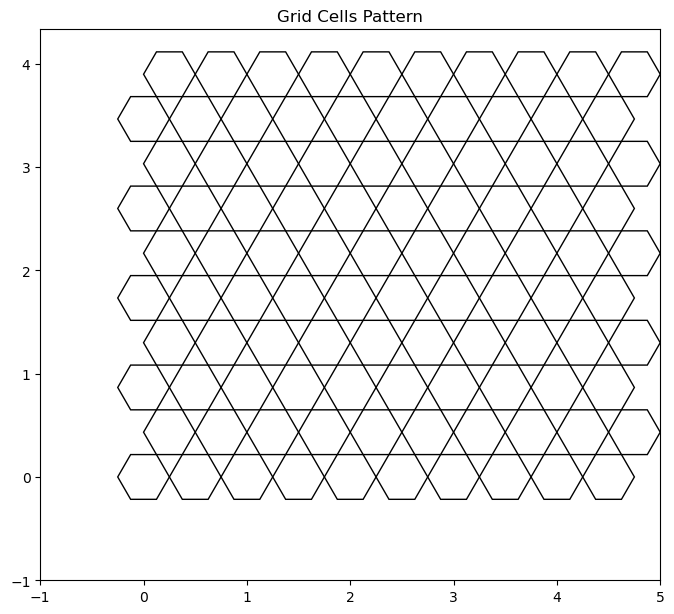

In [5]:
draw_grid_cells(10, 10, spacing=0.5)

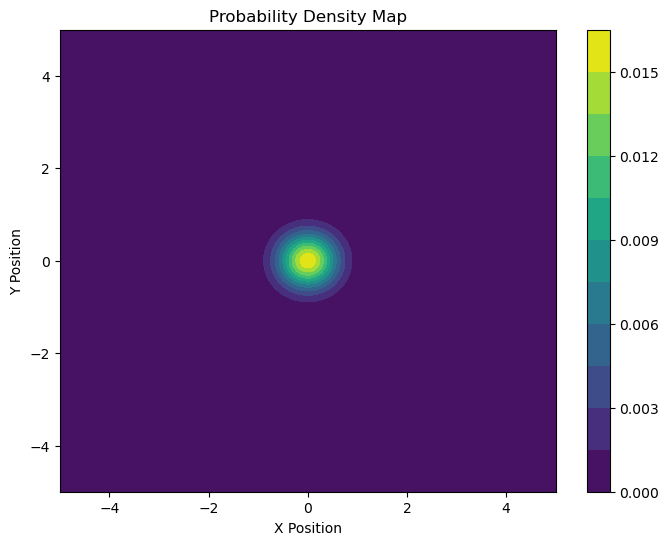

In [6]:
N = 2  # 尺度数量
n = [1, 2]  # 每个尺度对应的参数 n_j
sigma = [0.5, 1.0]  # 对应于 Omega_j(x) 的标准差，用于模拟高斯分布

def omega(x, y, sigma):
    """简化版的 Omega 函数，使用二维高斯分布"""
    return np.exp(-0.5 * (x**2 + y**2) / sigma**2) / (2 * np.pi * sigma**2)

# 创建网格
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
x, y = np.meshgrid(x, y)

# 计算概率密度
probability_density = np.ones_like(x)
for j in range(N):
    probability_density *= np.exp(n[j] * np.log(omega(x, y, sigma[j])))

# 绘制图像
plt.figure(figsize=(8, 6))
contour = plt.contourf(x, y, probability_density, levels=15, cmap='viridis')
plt.colorbar(contour)
plt.title('Probability Density Map')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.show()

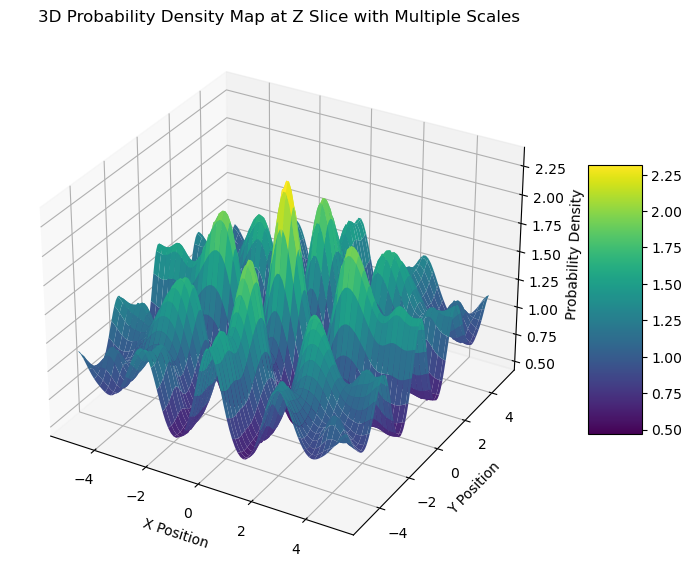

In [8]:
# 定义三个尺度的参数
scales = [
    {"n_max": 1.0, "k": 1.0, "omega": 2.0},  # 尺度1
    {"n_max": 0.8, "k": 1.5, "omega": 2.5},  # 尺度2
    {"n_max": 0.6, "k": 2.0, "omega": 3.0}   # 尺度3
]

def omega_function(x, y, z, n_max, k, omega):
    """定义给定的 Omega 函数"""
    k_vectors = [
        np.array([1, 0, 0]),  # x 方向单位向量
        np.array([0, 1, 0]),  # y 方向单位向量
        np.array([0, 0, 1])   # z 方向单位向量
    ]
    
    sum_term = 0
    for l in range(3):
        dot_product = k_vectors[l][0]*x + k_vectors[l][1]*y + k_vectors[l][2]*z
        sum_term += np.cos(omega * dot_product) - 1
    
    return n_max * np.exp((k/3) * sum_term)

# 创建网格
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
z = np.linspace(-5, 5, 100)
x, y, z = np.meshgrid(x, y, z)

# 计算总的概率密度
total_probability_density = np.zeros_like(x)
for scale in scales:
    total_probability_density += omega_function(x, y, z, scale["n_max"], scale["k"], scale["omega"])

# 因为三维数据难以直接可视化，我们只选取一个切片进行展示
slice_index = 50  # 选择中间的一个切片
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 绘制选定切片的概率密度
surf = ax.plot_surface(x[:, :, slice_index], y[:, :, slice_index], total_probability_density[:, :, slice_index],
                       cmap='viridis', edgecolor='none')

# 添加颜色条表示概率密度
fig.colorbar(surf, shrink=0.5, aspect=5)

# 设置标签
ax.set_title('3D Probability Density Map at Z Slice with Multiple Scales')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Probability Density')

plt.show()